# Libraries

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the data + printing

In [81]:
Data = pd.read_csv('DataSets/credit.csv',delimiter=',',na_values='unknown')
# Data=Data.drop(["foreign_worker","telephone","personal_status"], axis=1)
Data=pd.get_dummies(Data, dtype=float)


print(Data)

     months_loan_duration  amount  installment_rate  residence_history  age  \
0                       6    1169                 4                  4   67   
1                      48    5951                 2                  2   22   
2                      12    2096                 2                  3   49   
3                      42    7882                 2                  4   45   
4                      24    4870                 3                  4   53   
..                    ...     ...               ...                ...  ...   
995                    12    1736                 3                  4   31   
996                    30    3857                 4                  4   40   
997                    12     804                 4                  4   38   
998                    45    1845                 4                  4   23   
999                    45    4576                 3                  4   27   

     existing_credits  dependents  default  checkin

# The models

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn . model_selection import train_test_split

X=Data.drop("default",axis=1)
y=Data["default"]

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.4 )

gini_model = DecisionTreeClassifier(criterion='gini', random_state=30)
gini_model.fit(X_train,y_train)

info_gain_model = DecisionTreeClassifier(criterion='entropy', random_state=30)
info_gain_model.fit(X_train,y_train)



DecisionTreeClassifier(criterion='entropy', random_state=30)

In [83]:
tree_ = gini_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")
        

Number of nodes: 229
Node 0: Split on feature 8 <= 0.50
Node 1: Split on feature 7 <= 0.50
Node 2: Split on feature 45 <= 0.50
Node 3: Split on feature 38 <= 0.50
Node 4: Split on feature 15 <= 0.50
Node 5: Split on feature 4 <= 31.50
Node 6: Split on feature 2 <= 3.50
Node 7: Split on feature 3 <= 2.50
Node 8: Leaf node with impurity 0.00
Node 9: Split on feature 3 <= 3.50
Node 10: Split on feature 43 <= 0.50
Node 11: Leaf node with impurity 0.00
Node 12: Leaf node with impurity 0.00
Node 13: Split on feature 4 <= 29.50
Node 14: Leaf node with impurity 0.00
Node 15: Leaf node with impurity 0.00
Node 16: Split on feature 11 <= 0.50
Node 17: Split on feature 16 <= 0.50
Node 18: Split on feature 33 <= 0.50
Node 19: Split on feature 4 <= 23.50
Node 20: Split on feature 14 <= 0.50
Node 21: Leaf node with impurity 0.00
Node 22: Split on feature 30 <= 0.50
Node 23: Leaf node with impurity 0.00
Node 24: Leaf node with impurity 0.00
Node 25: Split on feature 19 <= 0.50
Node 26: Leaf node with 

In [97]:
tree_ = info_gain_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")

Number of nodes: 235
Node 0: Split on feature 8 <= 0.50
Node 1: Split on feature 7 <= 0.50
Node 2: Split on feature 46 <= 0.50
Node 3: Split on feature 33 <= 0.50
Node 4: Split on feature 4 <= 44.50
Node 5: Split on feature 3 <= 1.50
Node 6: Leaf node with impurity 0.00
Node 7: Split on feature 4 <= 40.50
Node 8: Split on feature 11 <= 0.50
Node 9: Split on feature 1 <= 790.00
Node 10: Leaf node with impurity 0.00
Node 11: Split on feature 30 <= 0.50
Node 12: Split on feature 16 <= 0.50
Node 13: Split on feature 32 <= 0.50
Node 14: Leaf node with impurity 0.00
Node 15: Split on feature 43 <= 0.50
Node 16: Leaf node with impurity 0.00
Node 17: Leaf node with impurity 0.00
Node 18: Leaf node with impurity 0.00
Node 19: Split on feature 48 <= 0.50
Node 20: Leaf node with impurity 0.00
Node 21: Leaf node with impurity 0.00
Node 22: Leaf node with impurity 0.00
Node 23: Leaf node with impurity 0.00
Node 24: Leaf node with impurity 0.00
Node 25: Leaf node with impurity 0.00
Node 26: Split on

# Comparing the models

In [85]:
print(" ---Gini index model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = gini_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

print("\n ---Information Gain model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = info_gain_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

 ---Gini index model :


Accuracy :  68.1667 %
Standard Deviation : 3.9051 %

 ---Information Gain model :
Accuracy :  68.3333 %
Standard Deviation : 4.0825 %


# Visualizing the results

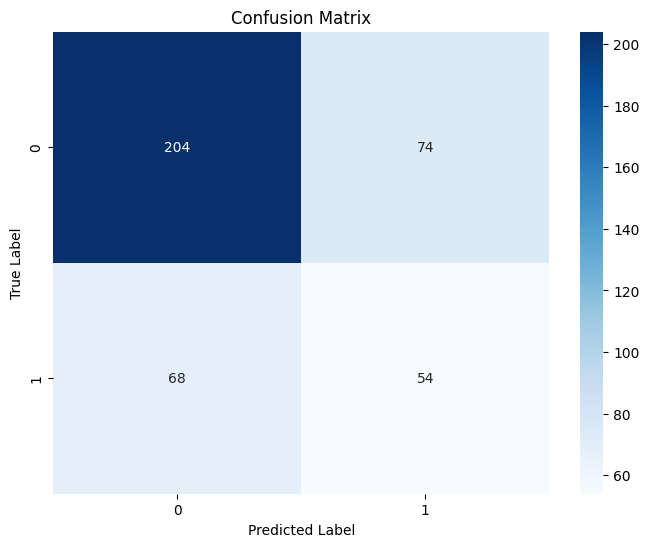

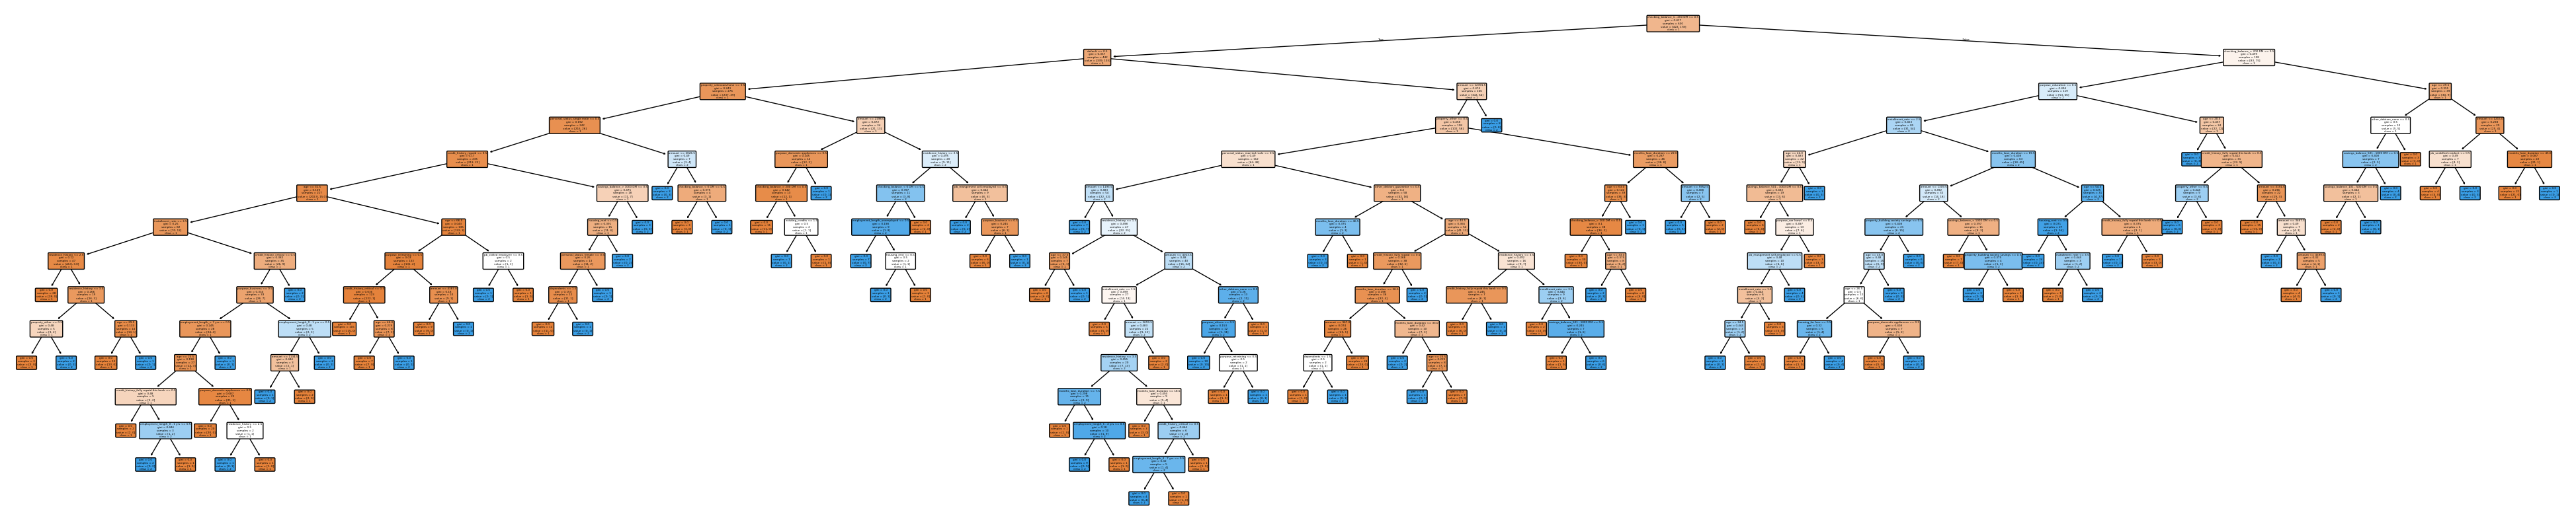

In [ ]:
from sklearn . metrics import confusion_matrix
import seaborn as sns

from sklearn. tree import plot_tree

y_pred = gini_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


plt.figure(figsize =(50,10))
plot_tree(gini_model, filled=True, feature_names=Data.columns[0:-1], class_names=['1','2'], rounded=True, fontsize=3)
plt.show()


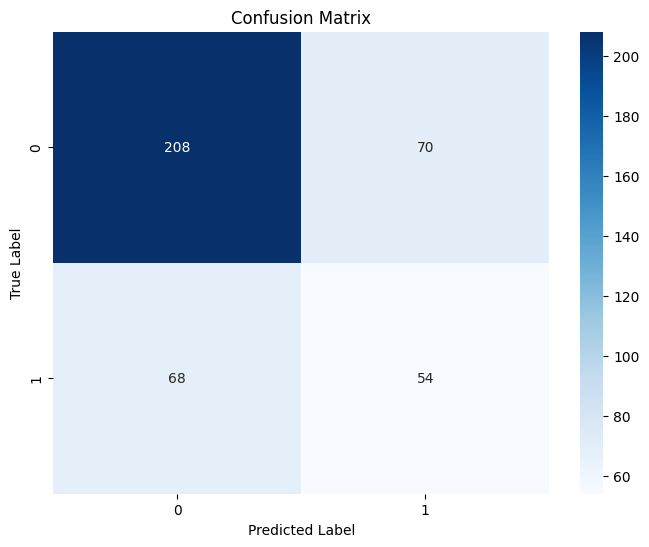

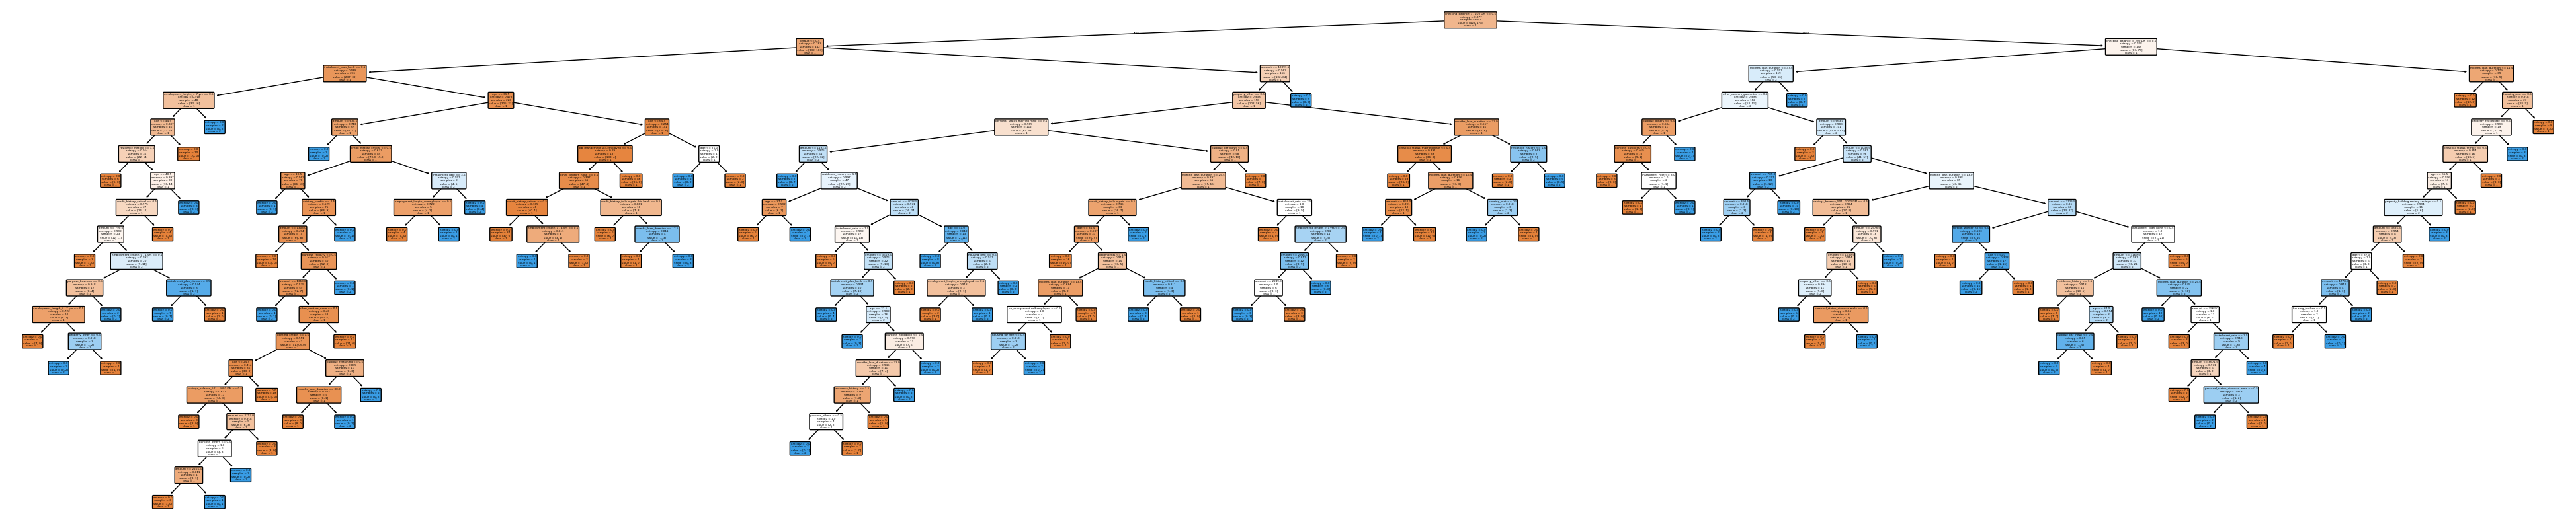

In [95]:
y_pred = info_gain_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


plt.figure(figsize =(50,10))
plot_tree(info_gain_model, filled=True, feature_names=Data.columns[0:-1], class_names=['1','2'], rounded=True, fontsize=3)
plt.show()
